In [ ]:

from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

OUTPUT_DIR = Path("saida_analise")
REPORT_DIR = OUTPUT_DIR / "relatorio_grafico"
REPORT_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:

def slugify(text):
    text = unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("utf-8")
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text

def save_current_fig(name, dpi=150):
    path = REPORT_DIR / f"{slugify(name)}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Figura salva em: {path}")
    return path

def read_exported_outputs(output_dir):
    summary_path = output_dir / "resumo_dataset.csv"
    dictionary_path = output_dir / "dicionario_de_dados.csv"
    excel_path = output_dir / "analise_completa.xlsx"

    dataset_summary = pd.read_csv(summary_path)
    data_dictionary = pd.read_csv(dictionary_path)
    xls = pd.ExcelFile(excel_path)

    all_sheets = {}
    for sheet in xls.sheet_names:
        all_sheets[sheet] = pd.read_excel(excel_path, sheet_name=sheet)

    dirty_sheets = {k.replace("sujeiras_", "", 1): v for k, v in all_sheets.items() if k.startswith("sujeiras_")}
    clean_sheets = {k.replace("limpo_", "", 1): v for k, v in all_sheets.items() if k.startswith("limpo_")}
    grouped_sheets = {k.replace("agrup_", "", 1): v for k, v in all_sheets.items() if k.startswith("agrup_")}

    return dataset_summary, data_dictionary, all_sheets, dirty_sheets, clean_sheets, grouped_sheets

dataset_summary, data_dictionary, all_sheets, dirty_sheets, clean_sheets, grouped_sheets = read_exported_outputs(OUTPUT_DIR)
print(list(all_sheets.keys()))


['Resumo Dataset', 'Dicionario de Dados', 'sujeiras_Programa', 'sujeiras_Proposta', 'sujeiras_Financiadores', 'sujeiras_Linhas de Pesquisa', 'sujeiras_Projetos de Pesquisa', 'sujeiras_Disciplinas', 'sujeiras_Turmas', 'sujeiras_Docentes', 'sujeiras_Discentes', 'sujeiras_Participantes Externos', 'sujeiras_Trabalhos de Conclusão', 'sujeiras_Produção Intelectual', 'sujeiras_Produções Mais Relevan', 'sujeiras_Pós-Doc', 'sujeiras_Projeto de Cooperação ', 'sujeiras_Egresso', 'limpo_Programa', 'limpo_Proposta', 'limpo_Financiadores', 'limpo_Linhas de Pesquisa', 'limpo_Projetos de Pesquisa', 'limpo_Disciplinas', 'limpo_Turmas', 'limpo_Docentes', 'limpo_Discentes', 'limpo_Participantes Externos', 'limpo_Trabalhos de Conclusão', 'limpo_Produção Intelectual', 'limpo_Produções Mais Relevantes', 'limpo_Pós-Doc', 'limpo_Projeto de Cooperação ent', 'limpo_Egresso']


In [ ]:

display(dataset_summary)


print(f"Total de abas no resumo: {len(dataset_summary)}")
print(f"Total de linhas no dicionário de dados: {len(data_dictionary)}")
print(f"Total de relatórios de sujeira: {len(dirty_sheets)}")
print(f"Total de planilhas limpas: {len(clean_sheets)}")
print(f"Total de planilhas agrupadas: {len(grouped_sheets)}")


,aba,linhas,colunas,celulas,colunas_totalmente_vazias,linhas_totalmente_vazias,percentual_ausencia_global
0,Produção Intelectual,1801,21,37821,0,0,16.32
1,Projetos de Pesquisa,122,24,2928,0,0,23.19
2,Participantes Externos,57,13,741,0,0,7.29
3,Discentes,44,18,792,0,0,8.08
4,Disciplinas,38,13,494,0,0,0.00
5,Trabalhos de Conclusão,30,17,510,0,0,11.76
6,Financiadores,30,13,390,0,0,0.00
7,Egresso,19,11,209,0,0,0.00
8,Docentes,18,15,270,0,0,5.93
9,Turmas,12,17,204,0,0,0.00


Total de abas no resumo: 16
Total de linhas no dicionário de dados: 186
Total de relatórios de sujeira: 16
Total de planilhas limpas: 16
Total de planilhas agrupadas: 0


Figura salva em: saida_analise/relatorio_grafico/01_volume_linhas_por_aba.png


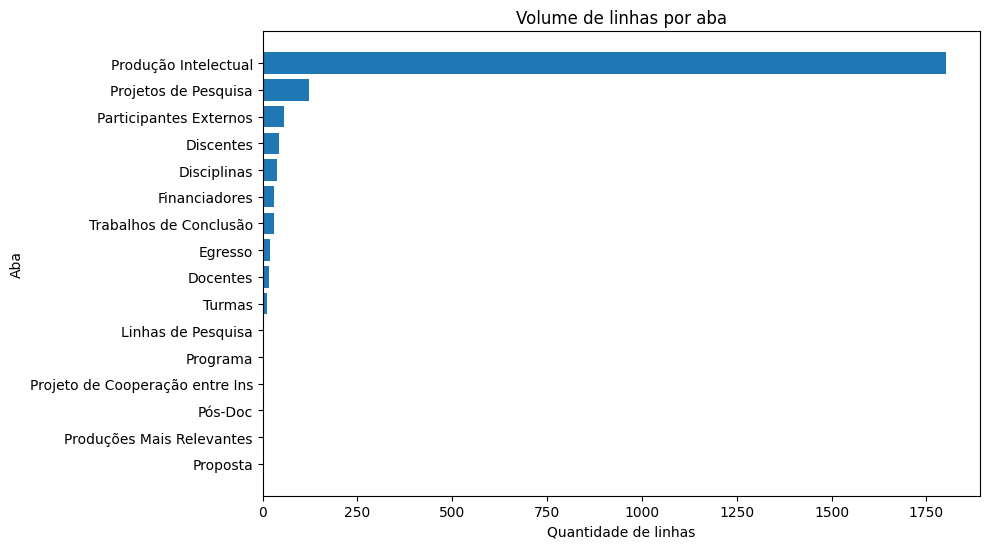

In [ ]:

plot_df = dataset_summary.sort_values("linhas", ascending=True)

plt.figure(figsize=(10, max(5, len(plot_df) * 0.35)))
plt.barh(plot_df["aba"], plot_df["linhas"])
plt.xlabel("Quantidade de linhas")
plt.ylabel("Aba")
plt.title("Volume de linhas por aba")
save_current_fig("01_volume_linhas_por_aba")
plt.show()


Figura salva em: saida_analise/relatorio_grafico/02_volume_colunas_por_aba.png


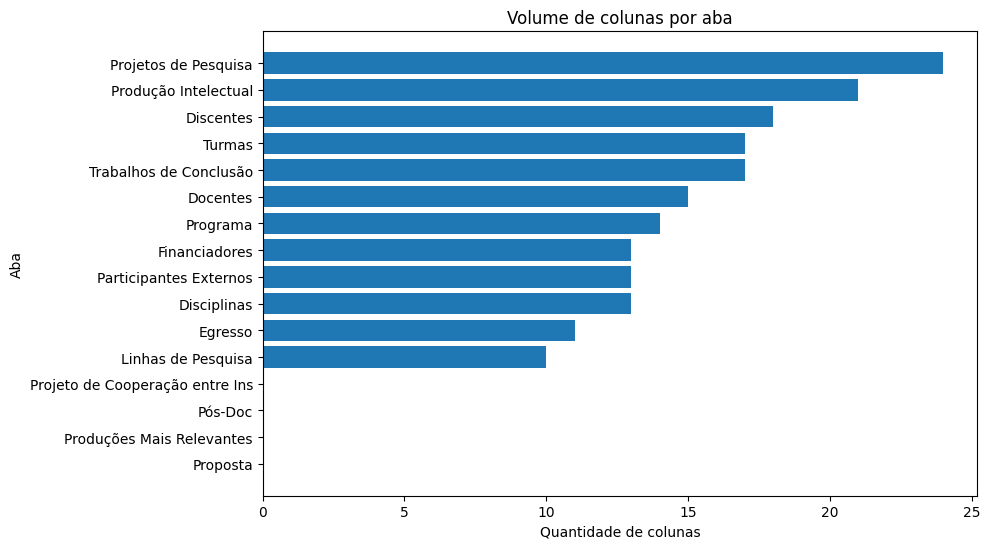

In [ ]:

plot_df = dataset_summary.sort_values("colunas", ascending=True)

plt.figure(figsize=(10, max(5, len(plot_df) * 0.35)))
plt.barh(plot_df["aba"], plot_df["colunas"])
plt.xlabel("Quantidade de colunas")
plt.ylabel("Aba")
plt.title("Volume de colunas por aba")
save_current_fig("02_volume_colunas_por_aba")
plt.show()


Figura salva em: saida_analise/relatorio_grafico/03_ausencia_global_por_aba.png


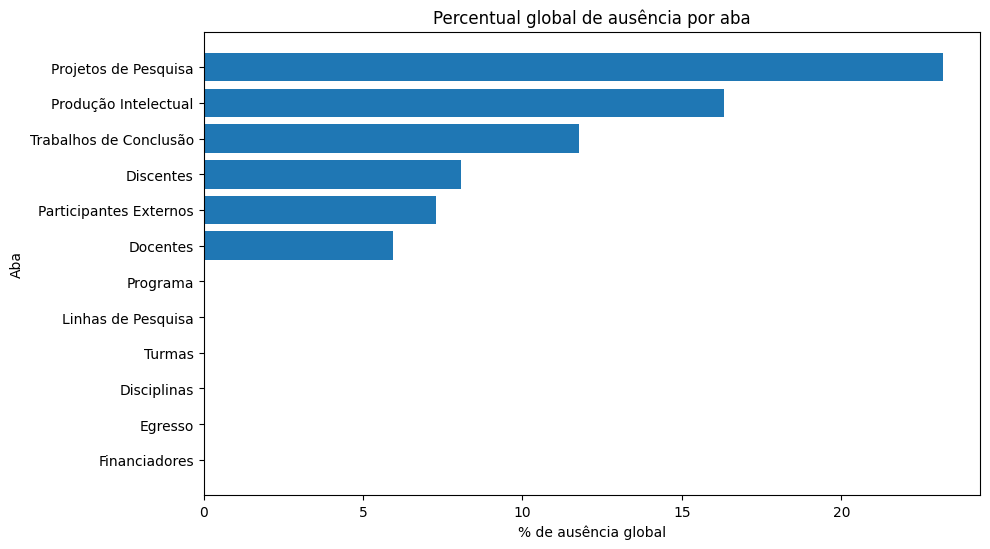

In [ ]:

plot_df = dataset_summary.sort_values("percentual_ausencia_global", ascending=True)

plt.figure(figsize=(10, max(5, len(plot_df) * 0.35)))
plt.barh(plot_df["aba"], plot_df["percentual_ausencia_global"])
plt.xlabel("% de ausência global")
plt.ylabel("Aba")
plt.title("Percentual global de ausência por aba")
save_current_fig("03_ausencia_global_por_aba")
plt.show()


,tipo_logico,quantidade
0,categorica_textual,126
1,data_textual,20
2,inteiro,19
3,texto_livre,10
4,booleano_textual,9
5,numerico_continuo,2


Figura salva em: saida_analise/relatorio_grafico/04_distribuicao_tipos_logicos.png


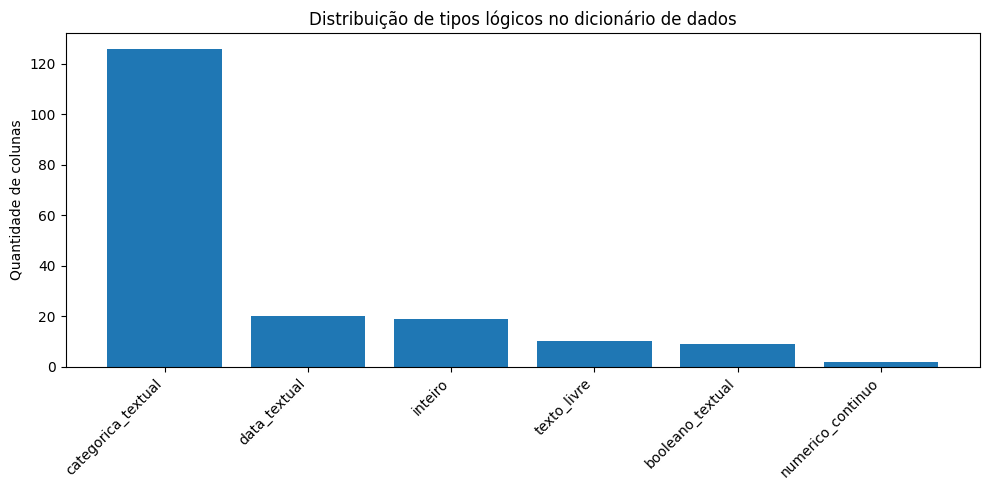

In [ ]:

type_dist = (
    data_dictionary["tipo_logico"]
    .fillna("nao_classificado")
    .value_counts()
    .rename_axis("tipo_logico")
    .reset_index(name="quantidade")
)

display(type_dist)

plt.figure(figsize=(10, 5))
plt.bar(type_dist["tipo_logico"], type_dist["quantidade"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Quantidade de colunas")
plt.title("Distribuição de tipos lógicos no dicionário de dados")
save_current_fig("04_distribuicao_tipos_logicos")
plt.show()


In [ ]:

dict_summary = (
    data_dictionary
    .groupby("aba", as_index=False)
    .agg(
        colunas=("coluna", "count"),
        colunas_com_na=("pct_na", lambda x: int((x > 0).sum())),
        media_pct_na=("pct_na", "mean"),
        categorias=("tipo_logico", lambda x: (x == "categorica_textual").sum()),
        datas=("tipo_logico", lambda x: ((x == "data_textual") | (x == "datetime")).sum()),
        numericas=("tipo_logico", lambda x: x.isin(["inteiro", "numerico_continuo", "numerico_textual"]).sum()),
        texto_livre=("tipo_logico", lambda x: (x == "texto_livre").sum())
    )
)

dict_summary["media_pct_na"] = dict_summary["media_pct_na"].round(2)
display(dict_summary.sort_values("media_pct_na", ascending=False))


,aba,colunas,colunas_com_na,media_pct_na,categorias,datas,numericas,texto_livre
9,Projetos de Pesquisa,24,10,23.19,14,3,2,3
7,Produção Intelectual,21,8,16.32,13,1,3,3
10,Trabalhos de Conclusão,17,4,11.76,12,2,1,0
0,Discentes,18,6,8.08,12,3,1,1
6,Participantes Externos,13,1,7.29,8,2,1,1
2,Docentes,15,1,5.93,10,2,3,0
3,Egresso,11,0,0.00,8,1,2,0
1,Disciplinas,13,0,0.00,9,1,2,1
4,Financiadores,13,0,0.00,8,1,2,1
5,Linhas de Pesquisa,10,0,0.00,8,1,1,0


Figura salva em: saida_analise/relatorio_grafico/05_heatmap_qualidade_por_aba.png


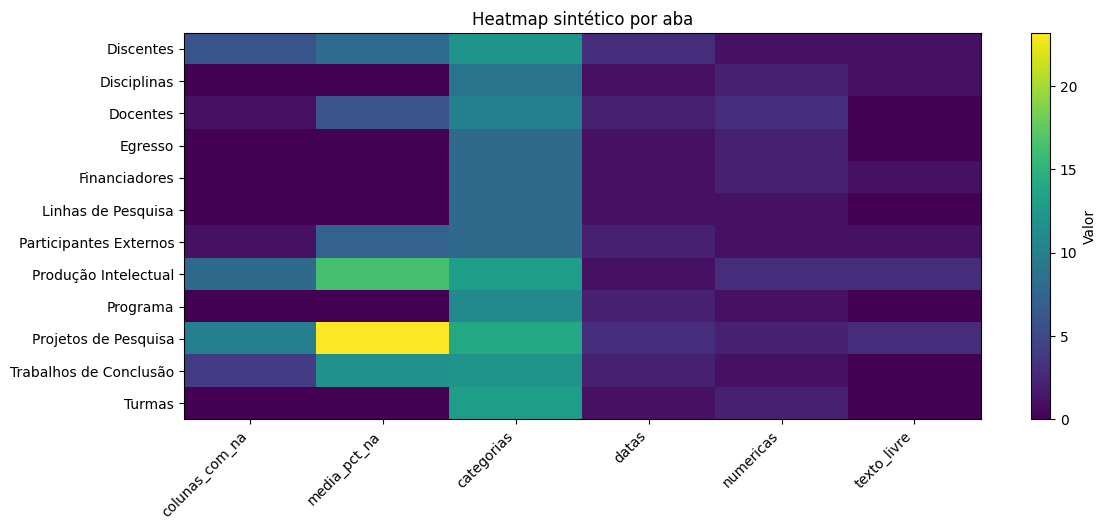

In [ ]:

quality_df = dict_summary.copy()
quality_df = quality_df.set_index("aba")[["colunas_com_na", "media_pct_na", "categorias", "datas", "numericas", "texto_livre"]]

plt.figure(figsize=(12, max(5, len(quality_df) * 0.45)))
plt.imshow(quality_df.values, aspect="auto")
plt.colorbar(label="Valor")
plt.xticks(range(len(quality_df.columns)), quality_df.columns, rotation=45, ha="right")
plt.yticks(range(len(quality_df.index)), quality_df.index)
plt.title("Heatmap sintético por aba")
save_current_fig("05_heatmap_qualidade_por_aba")
plt.show()


In [ ]:

dirty_long = []
for sheet_name, df in dirty_sheets.items():
    temp = df.copy()
    temp["aba"] = sheet_name
    dirty_long.append(temp)

dirty_long = pd.concat(dirty_long, ignore_index=True) if dirty_long else pd.DataFrame()
display(dirty_long.head(20))


,coluna,nulos,pct_nulos,duplicados_na_coluna,espacos_inicio_fim,multiplos_espacos,placeholders_ausencia,datas_invalidas,valores_unicos,coluna_constante,aba
0,Calendário,0,0.0,0,0,0,0,0,1,True,Programa
1,Ano do Calendário,0,0.0,0,0,0,0,0,1,True,Programa
2,Data-Hora do Envio,0,0.0,0,0,0,0,0,1,True,Programa
3,Código do PPG,0,0.0,0,0,0,0,0,1,True,Programa
4,Nome do PPG,0,0.0,0,0,0,0,0,1,True,Programa
5,Área de Avaliação,0,0.0,0,0,0,0,0,1,True,Programa
6,Área Básica,0,0.0,0,0,0,0,0,1,True,Programa
7,Regime Letivo,0,0.0,0,0,0,0,0,1,True,Programa
8,IES Sigla,0,0.0,0,0,0,0,0,1,True,Programa
9,IES Nome,0,0.0,0,0,0,0,0,1,True,Programa


,aba,coluna,pct_nulos,placeholders_ausencia,datas_invalidas,espacos_inicio_fim,multiplos_espacos,coluna_constante,score_sujeira
155,Produção Intelectual,Categoria do Autor,84.40,1520,0,0,0,False,2448.80
154,Produção Intelectual,Nome do Autor,84.40,1520,0,0,0,False,2448.80
157,Produção Intelectual,Valor do Detalhamento,59.91,1079,0,0,0,False,1738.32
158,Produção Intelectual,Nome do Detalhamento,15.60,281,0,0,0,False,452.70
39,Projetos de Pesquisa,Financiador Estrangeiro (Sim/Não),92.62,113,0,0,0,True,364.74
37,Projetos de Pesquisa,Data Fim Financiador,95.08,116,0,0,0,False,364.16
38,Projetos de Pesquisa,Nome do Financiador,92.62,113,0,0,0,False,354.74
40,Projetos de Pesquisa,Data Início Financiador,92.62,113,0,0,0,False,354.74
159,Produção Intelectual,Projeto de Pesquisa,10.16,183,0,0,0,False,294.82
124,Participantes Externos,Data Fim,94.74,54,0,0,0,False,270.48


Figura salva em: saida_analise/relatorio_grafico/06_top_colunas_problematicas.png


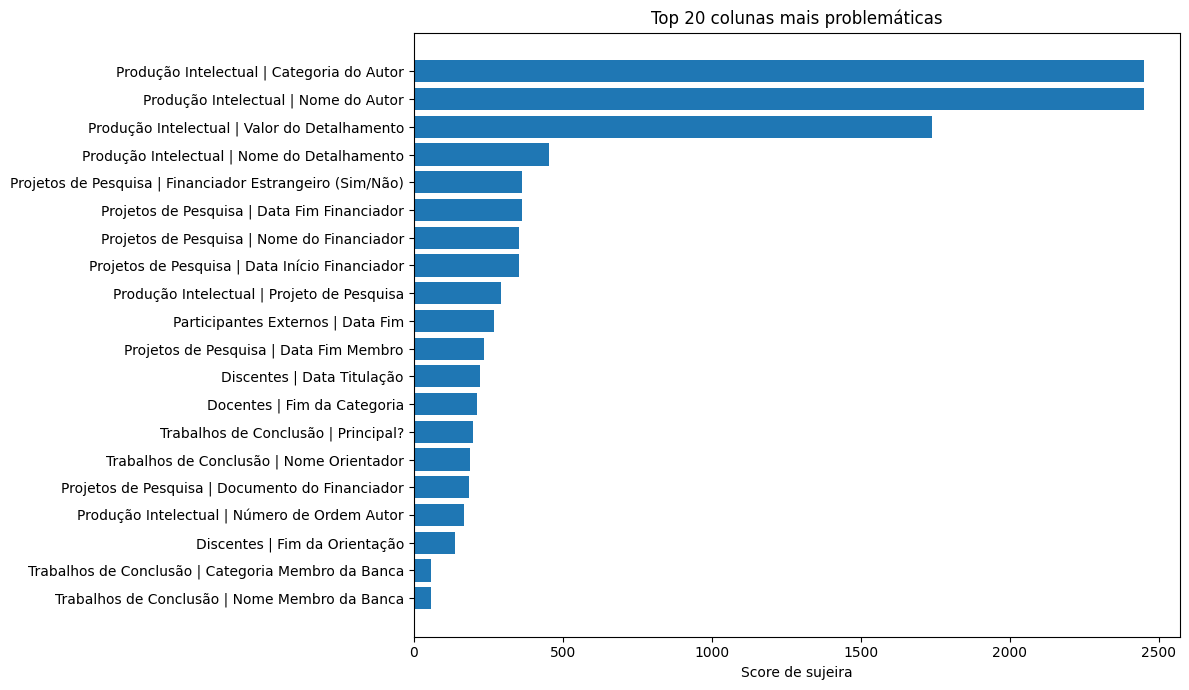

In [ ]:

if not dirty_long.empty:
    dirty_long["score_sujeira"] = (
        dirty_long["pct_nulos"].fillna(0) * 2
        + dirty_long["placeholders_ausencia"].fillna(0) * 1.5
        + dirty_long["datas_invalidas"].fillna(0) * 1.5
        + dirty_long["espacos_inicio_fim"].fillna(0) * 1.0
        + dirty_long["multiplos_espacos"].fillna(0) * 1.0
        + dirty_long["coluna_constante"].fillna(False).astype(int) * 10
    )

    top_dirty = (
        dirty_long
        .sort_values("score_sujeira", ascending=False)
        .loc[:, ["aba", "coluna", "pct_nulos", "placeholders_ausencia", "datas_invalidas",
                 "espacos_inicio_fim", "multiplos_espacos", "coluna_constante", "score_sujeira"]]
        .head(20)
    )

    display(top_dirty)

    plt.figure(figsize=(12, 7))
    labels = top_dirty["aba"] + " | " + top_dirty["coluna"]
    plt.barh(labels[::-1], top_dirty["score_sujeira"][::-1])
    plt.xlabel("Score de sujeira")
    plt.title("Top 20 colunas mais problemáticas")
    save_current_fig("06_top_colunas_problematicas")
    plt.show()


,aba,media_pct_nulos,max_pct_nulos,n_colunas
1,Disciplinas,0.000000,0.00,13
3,Egresso,0.000000,0.00,11
5,Linhas de Pesquisa,0.000000,0.00,10
4,Financiadores,0.000000,0.00,13
11,Turmas,0.000000,0.00,17
8,Programa,0.000000,0.00,14
2,Docentes,5.926000,88.89,15
6,Participantes Externos,7.287692,94.74,13
0,Discentes,8.080000,84.09,18
10,Trabalhos de Conclusão,11.764706,76.67,17


Figura salva em: saida_analise/relatorio_grafico/07_ranking_ausencia_media_por_aba.png


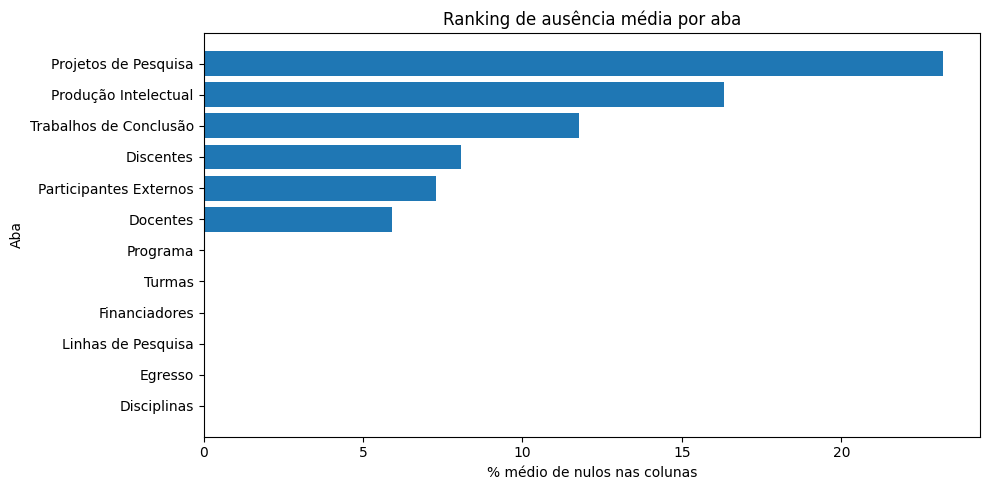

In [ ]:

if not dirty_long.empty:
    null_by_sheet = (
        dirty_long.groupby("aba", as_index=False)
        .agg(
            media_pct_nulos=("pct_nulos", "mean"),
            max_pct_nulos=("pct_nulos", "max"),
            n_colunas=("coluna", "count")
        )
        .sort_values("media_pct_nulos", ascending=True)
    )

    display(null_by_sheet)

    plt.figure(figsize=(10, max(5, len(null_by_sheet) * 0.35)))
    plt.barh(null_by_sheet["aba"], null_by_sheet["media_pct_nulos"])
    plt.xlabel("% médio de nulos nas colunas")
    plt.ylabel("Aba")
    plt.title("Ranking de ausência média por aba")
    save_current_fig("07_ranking_ausencia_media_por_aba")
    plt.show()


In [ ]:

comparison_rows = []
for sheet_name, grouped_df in grouped_sheets.items():
    clean_df = clean_sheets.get(sheet_name)
    if clean_df is not None:
        comparison_rows.append({
            "aba": sheet_name,
            "linhas_limpo": len(clean_df),
            "linhas_agrupado": len(grouped_df),
            "reducao_absoluta": len(clean_df) - len(grouped_df),
            "reducao_percentual": round(((len(clean_df) - len(grouped_df)) / len(clean_df) * 100), 2) if len(clean_df) else 0
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

if not comparison_df.empty:
    plot_df = comparison_df.sort_values("reducao_percentual", ascending=True)
    plt.figure(figsize=(10, max(4, len(plot_df) * 0.6)))
    plt.barh(plot_df["aba"], plot_df["reducao_percentual"])
    plt.xlabel("% de redução após agrupamento")
    plt.title("Impacto do agrupamento por entidade lógica")
    save_current_fig("08_reducao_pos_agrupamento")
    plt.show()


""


,aba,pct_nulos,placeholders,datas_invalidas,espacos,colunas_constantes,score_qualidade_invertido
5,Linhas de Pesquisa,0.000000,0,0,0,8,24.000000
4,Financiadores,0.000000,0,0,0,8,24.000000
3,Egresso,0.000000,0,0,0,9,27.000000
1,Disciplinas,0.000000,0,0,0,11,33.000000
11,Turmas,0.000000,0,0,0,13,39.000000
8,Programa,0.000000,0,0,0,14,42.000000
2,Docentes,5.926000,16,0,0,9,48.926000
6,Participantes Externos,7.287692,54,0,0,8,85.287692
0,Discentes,8.080000,64,0,0,10,102.080000
10,Trabalhos de Conclusão,11.764706,60,0,0,11,104.764706


Figura salva em: saida_analise/relatorio_grafico/09_score_problema_por_aba.png


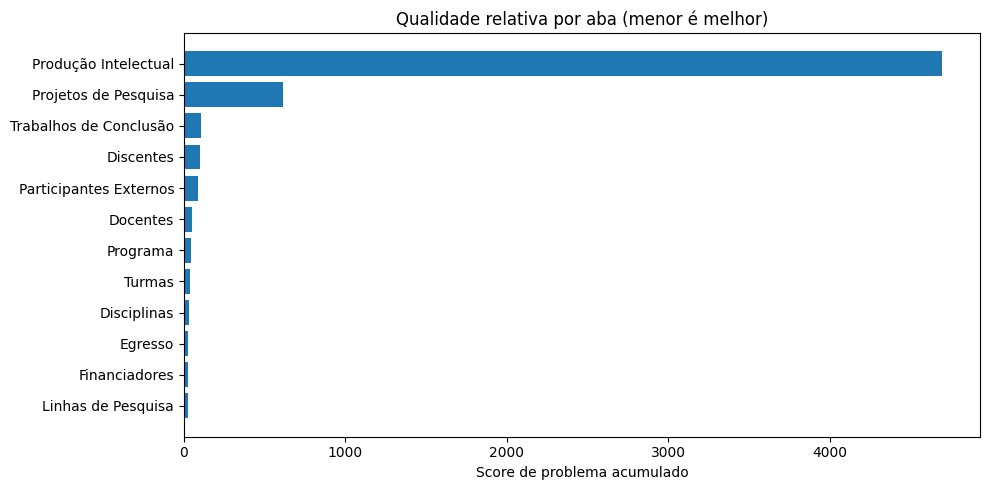

In [ ]:

if not dirty_long.empty:
    radar_base = (
        dirty_long.groupby("aba", as_index=False)
        .agg(
            pct_nulos=("pct_nulos", "mean"),
            placeholders=("placeholders_ausencia", "sum"),
            datas_invalidas=("datas_invalidas", "sum"),
            espacos=("espacos_inicio_fim", "sum"),
            colunas_constantes=("coluna_constante", "sum")
        )
    )

    radar_base["score_qualidade_invertido"] = (
        radar_base["pct_nulos"].fillna(0)
        + radar_base["placeholders"].fillna(0)
        + radar_base["datas_invalidas"].fillna(0)
        + radar_base["espacos"].fillna(0)
        + radar_base["colunas_constantes"].fillna(0) * 3
    )

    radar_base = radar_base.sort_values("score_qualidade_invertido", ascending=True)
    display(radar_base.head(20))

    plt.figure(figsize=(10, max(5, len(radar_base) * 0.35)))
    plt.barh(radar_base["aba"], radar_base["score_qualidade_invertido"])
    plt.xlabel("Score de problema acumulado")
    plt.title("Qualidade relativa por aba (menor é melhor)")
    save_current_fig("09_score_problema_por_aba")
    plt.show()


In [ ]:

def generate_text_report(dataset_summary, data_dictionary, dirty_long, comparison_df):
    lines = []

    lines.append("# Relatório textual automático")
    lines.append("")
    lines.append("## 1. Visão geral")
    lines.append(f"- Total de abas analisadas: **{len(dataset_summary)}**.")
    lines.append(f"- Total de colunas documentadas: **{len(data_dictionary)}**.")
    lines.append(f"- Total de linhas somadas entre abas: **{int(dataset_summary['linhas'].sum())}**.")
    lines.append("")

    if not dataset_summary.empty:
        largest = dataset_summary.sort_values("linhas", ascending=False).iloc[0]
        smallest = dataset_summary.sort_values("linhas", ascending=True).iloc[0]
        worst_missing = dataset_summary.sort_values("percentual_ausencia_global", ascending=False).iloc[0]

        lines.append("## 2. Destaques estruturais")
        lines.append(f"- Aba com maior volume: **{largest['aba']}** ({int(largest['linhas'])} linhas).")
        lines.append(f"- Aba com menor volume: **{smallest['aba']}** ({int(smallest['linhas'])} linhas).")
        lines.append(f"- Maior ausência global: **{worst_missing['aba']}** ({worst_missing['percentual_ausencia_global']:.2f}%).")
        lines.append("")

    if not data_dictionary.empty:
        type_counts = data_dictionary["tipo_logico"].fillna("nao_classificado").value_counts()
        lines.append("## 3. Tipos lógicos")
        for idx, val in type_counts.items():
            lines.append(f"- {idx}: **{int(val)}** colunas.")
        lines.append("")

    if dirty_long is not None and not dirty_long.empty:
        dirty_tmp = dirty_long.copy()
        dirty_tmp["score_sujeira"] = (
            dirty_tmp["pct_nulos"].fillna(0) * 2
            + dirty_tmp["placeholders_ausencia"].fillna(0) * 1.5
            + dirty_tmp["datas_invalidas"].fillna(0) * 1.5
            + dirty_tmp["espacos_inicio_fim"].fillna(0)
            + dirty_tmp["multiplos_espacos"].fillna(0)
            + dirty_tmp["coluna_constante"].fillna(False).astype(int) * 10
        )
        top5 = dirty_tmp.sort_values("score_sujeira", ascending=False).head(5)

        lines.append("## 4. Principais pontos de atenção")
        for _, row in top5.iterrows():
            lines.append(
                f"- **{row['aba']} / {row['coluna']}**: score {row['score_sujeira']:.2f}, "
                f"{row['pct_nulos']:.2f}% de nulos, "
                f"{int(row['placeholders_ausencia'])} placeholders, "
                f"{int(row['datas_invalidas'])} datas inválidas."
            )
        lines.append("")

    if comparison_df is not None and not comparison_df.empty:
        lines.append("## 5. Efeito do agrupamento")
        for _, row in comparison_df.sort_values("reducao_percentual", ascending=False).iterrows():
            lines.append(
                f"- **{row['aba']}**: redução de {row['reducao_absoluta']} linhas "
                f"({row['reducao_percentual']:.2f}%) após consolidação."
            )
        lines.append("")

    lines.append("## 6. Recomendação")
    lines.append("- Revisar primeiro as colunas com maior score de sujeira.")
    lines.append("- Priorizar correção das abas com maior ausência global.")
    lines.append("- Validar se reduções por agrupamento representam duplicidade esperada ou perda indevida de granularidade.")
    lines.append("- Reexecutar o pipeline para outros anos e comparar tendências.")
    lines.append("")

    return "\n".join(lines)

text_report = generate_text_report(dataset_summary, data_dictionary, dirty_long, comparison_df)
print(text_report)


# Relatório textual automático

## 1. Visão geral
- Total de abas analisadas: **16**.
- Total de colunas documentadas: **186**.
- Total de linhas somadas entre abas: **2175**.

## 2. Destaques estruturais
- Aba com maior volume: **Produção Intelectual** (1801 linhas).
- Aba com menor volume: **Proposta** (0 linhas).
- Maior ausência global: **Projetos de Pesquisa** (23.19%).

## 3. Tipos lógicos
- categorica_textual: **126** colunas.
- data_textual: **20** colunas.
- inteiro: **19** colunas.
- texto_livre: **10** colunas.
- booleano_textual: **9** colunas.
- numerico_continuo: **2** colunas.

## 4. Principais pontos de atenção
- **Produção Intelectual / Categoria do Autor**: score 2448.80, 84.40% de nulos, 1520 placeholders, 0 datas inválidas.
- **Produção Intelectual / Nome do Autor**: score 2448.80, 84.40% de nulos, 1520 placeholders, 0 datas inválidas.
- **Produção Intelectual / Valor do Detalhamento**: score 1738.32, 59.91% de nulos, 1079 placeholders, 0 datas inválidas.
- **Produç

In [ ]:

report_md_path = REPORT_DIR / "relatorio_textual.md"
report_html_path = REPORT_DIR / "relatorio_textual.html"

with open(report_md_path, "w", encoding="utf-8") as f:
    f.write(text_report)

html_content = f"""
<html>
<head>
    <meta charset="utf-8">
    <title>Relatório Gráfico</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 40px;
            line-height: 1.5;
        }}
        pre {{
            white-space: pre-wrap;
            font-family: Arial, sans-serif;
        }}
    </style>
</head>
<body>
<pre>{text_report}</pre>
</body>
</html>
"""

with open(report_html_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"Relatório markdown salvo em: {report_md_path}")
print(f"Relatório html salvo em: {report_html_path}")


Relatório markdown salvo em: saida_analise/relatorio_grafico/relatorio_textual.md
Relatório html salvo em: saida_analise/relatorio_grafico/relatorio_textual.html


In [ ]:

with pd.ExcelWriter(REPORT_DIR / "tabelas_relatorio_grafico.xlsx", engine="openpyxl") as writer:
    dataset_summary.to_excel(writer, sheet_name="resumo_dataset", index=False)
    data_dictionary.to_excel(writer, sheet_name="dicionario_dados", index=False)

    if not dirty_long.empty:
        dirty_long.to_excel(writer, sheet_name="sujeiras_consolidadas", index=False)

    if 'dict_summary' in globals():
        dict_summary.to_excel(writer, sheet_name="resumo_dicionario_por_aba", index=False)

    if 'comparison_df' in globals() and not comparison_df.empty:
        comparison_df.to_excel(writer, sheet_name="comparacao_agrupamento", index=False)

print(f"Tabelas auxiliares exportadas em: {REPORT_DIR / 'tabelas_relatorio_grafico.xlsx'}")


Tabelas auxiliares exportadas em: saida_analise/relatorio_grafico/tabelas_relatorio_grafico.xlsx



## Interpretação

- **Volume por aba** mostra onde está a maior massa de dados.
- **Ausência global** mostra quais abas estão mais frágeis em completude.
- **Tipos lógicos** ajudam a entender a estrutura semântica da base.
- **Top colunas problemáticas** orienta a priorização da limpeza.
- **Impacto do agrupamento** mostra redução de granularidade após consolidação de entidades.


In [ ]:

def run_graphical_report(output_dir=Path("saida_analise")):
    dataset_summary, data_dictionary, all_sheets, dirty_sheets, clean_sheets, grouped_sheets = read_exported_outputs(output_dir)
    print("Estrutura carregada com sucesso.")
    print(f"Resumo dataset: {dataset_summary.shape}")
    print(f"Dicionário de dados: {data_dictionary.shape}")
    print(f"Relatórios de sujeira: {len(dirty_sheets)}")
    print(f"Planilhas limpas: {len(clean_sheets)}")
    print(f"Planilhas agrupadas: {len(grouped_sheets)}")
    return {
        "dataset_summary": dataset_summary,
        "data_dictionary": data_dictionary,
        "all_sheets": all_sheets,
        "dirty_sheets": dirty_sheets,
        "clean_sheets": clean_sheets,
        "grouped_sheets": grouped_sheets
    }

# Exemplo:
results = run_graphical_report(OUTPUT_DIR)


Estrutura carregada com sucesso.
Resumo dataset: (16, 7)
Dicionário de dados: (186, 10)
Relatórios de sujeira: 16
Planilhas limpas: 16
Planilhas agrupadas: 0
